<a href="https://colab.research.google.com/github/NguyenNguyen1504/GROUP-5-BPFE/blob/main/GROUP_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **I. Load and clean datasets**



### **Setup path and read input**



In [1]:
from google.colab import drive
import os
import pandas as pd

drive.mount('/content/drive')

base_dataset_path = '/content/drive/MyDrive/EPL_data/results.csv'

if os.path.exists(base_dataset_path):
    df_results = pd.read_csv(base_dataset_path, encoding="latin1") # Base dataset
    print("Read data successfully.")
    display(df_results.head())
else:
    print("Error: file not found.")

Mounted at /content/drive
Read data successfully.


,Season,DateTime,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,...,HST,AST,HC,AC,HF,AF,HY,AY,HR,AR
0,1993-94,1993-08-14T00:00:00Z,Arsenal,Coventry,0,3,A,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1993-94,1993-08-14T00:00:00Z,Aston Villa,QPR,4,1,H,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1993-94,1993-08-14T00:00:00Z,Chelsea,Blackburn,1,2,A,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1993-94,1993-08-14T00:00:00Z,Liverpool,Sheffield Weds,2,0,H,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1993-94,1993-08-14T00:00:00Z,Man City,Leeds,1,1,D,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### **Clean data**

In [2]:
columns_to_keep = ['Season', 'DateTime', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR']
# 93-94 and 94-95 seasons had 22 teams
rows_to_drop = ['1993-94', '1994-95']
df_results = df_results[columns_to_keep].copy()
df_results = df_results[~df_results['Season'].isin(rows_to_drop)].copy()

### **Create dictionaries saving data of clubs' home stadiums capacities**

**Source: Wikipedia, NBC Sports** (https://www.nbcsports.com/soccer/news/list-of-premier-league-stadiums-every-clubs-current-and-former-ground-from-the-pl-era)

In [3]:
# Teams with changed stadiums
changes = {
    'Arsenal':       [('2006-07', 60704), ('1993-94', 38419)],
    'Man City':      [('2003-04', 53400), ('1993-94', 35150)],
    'Southampton':   [('2001-02', 32384), ('1993-94', 15200)],
    'Leicester':     [('2002-03', 32261), ('1993-94', 22000)],
    'Middlesbrough': [('1995-96', 34742), ('1993-94', 26667)],
    'West Ham':      [('2016-17', 60000), ('1993-94', 35016)],
    'Tottenham':     [('2019-20', 62850), ('1993-94', 36284)],
    'Bolton':        [('1997-98', 28723), ('1993-94', 22000)],
    'Sunderland':    [('1997-98', 49000), ('1993-94', 22000)]
}

# Teams with unchanged stadiums
fixed = {
    'Man United':       74197,
    'Liverpool':        54074,
    'Newcastle':        52258,
    'Aston Villa':      42785,
    'Chelsea':          40173,
    'Everton':          39414,
    'Sheffield Weds':   39812,
    'Leeds':            37890,
    'Blackburn':        31367,
    'Wolves':           32050,
    'Sheffield United': 32050,
    'Brighton':         31876,
    'Ipswich':          29813,
    'Birmingham':       29409,
    'Stoke':            27902,
    'Norwich':          27359,
    'Charlton':         27111,
    'West Brom':        26850,
    'Wimbledon':        26309,
    'Fulham':           25700,
    'Crystal Palace':   25486,
    'Hull':             25400,
    'Wigan':            25138,
    'Bradford':         25136,
    'Huddersfield':     24500,
    'Reading':          24161,
    'Barnsley':         23009,
    'Watford':          22200,
    'Burnley':          21944,
    'Swansea':          21088,
    'Portsmouth':       20700,
    'QPR':              18360,
    'Brentford':        17250,
    'Blackpool':        16220,
    'Swindon':          15728,
    'Oldham':           13512,
    'Bournemouth':      11307,
    'Derby':            33597,
    'Cardiff':          33280,
    'Coventry':         32609,
    "Nott'm Forest":    30404
}

### **Create a column for home stadium capacity in the big dataset**

In [4]:
def get_capacity(team, season):

    if team in changes:
        for from_season, cap in changes[team]:
            if season >= from_season:
                return cap

    if team in fixed:
        return fixed[team]

    print(f"WARNING: No capacity data for team '{team}'")
    return None

df_results['HomeTeam_StadiumCapacity'] = df_results.apply(lambda row: get_capacity(row['HomeTeam'],row['Season']), axis=1)
df_results = df_results.reset_index(drop=True)

display(df_results.head())

,Season,DateTime,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HomeTeam_StadiumCapacity
0,1995-96,1995-08-19T00:00:00Z,Aston Villa,Man United,3,1,H,42785
1,1995-96,1995-08-19T00:00:00Z,Blackburn,QPR,1,0,H,31367
2,1995-96,1995-08-19T00:00:00Z,Chelsea,Everton,0,0,D,40173
3,1995-96,1995-08-19T00:00:00Z,Liverpool,Sheffield Weds,1,0,H,54074
4,1995-96,1995-08-19T00:00:00Z,Man City,Tottenham,1,1,D,35150


In [5]:
df_results['CapacityGroup'] = pd.cut(
    df_results['HomeTeam_StadiumCapacity'],
    bins = 3,
    labels = ['Small', 'Medium', 'Large']
)

### **Assign the matches to the COVID period**

In [6]:
def covid_period(season):
  if season < '2020-21':
    return 'pre-COVID'
  elif season == '2020-21':
    return 'COVID'
  else:
    return 'post-COVID'

df_results['COVID_period'] = df_results['Season'].apply(lambda season: covid_period(season))
display(df_results.head(10))

,Season,DateTime,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HomeTeam_StadiumCapacity,CapacityGroup,COVID_period
0,1995-96,1995-08-19T00:00:00Z,Aston Villa,Man United,3,1,H,42785,Medium,pre-COVID
1,1995-96,1995-08-19T00:00:00Z,Blackburn,QPR,1,0,H,31367,Small,pre-COVID
2,1995-96,1995-08-19T00:00:00Z,Chelsea,Everton,0,0,D,40173,Medium,pre-COVID
3,1995-96,1995-08-19T00:00:00Z,Liverpool,Sheffield Weds,1,0,H,54074,Large,pre-COVID
4,1995-96,1995-08-19T00:00:00Z,Man City,Tottenham,1,1,D,35150,Medium,pre-COVID
5,1995-96,1995-08-19T00:00:00Z,Newcastle,Coventry,3,0,H,52258,Medium,pre-COVID
6,1995-96,1995-08-19T00:00:00Z,Southampton,Nott'm Forest,3,4,A,15200,Small,pre-COVID
7,1995-96,1995-08-19T00:00:00Z,West Ham,Leeds,1,2,A,35016,Medium,pre-COVID
8,1995-96,1995-08-19T00:00:00Z,Wimbledon,Bolton,3,2,H,26309,Small,pre-COVID
9,1995-96,1995-08-20T00:00:00Z,Arsenal,Middlesbrough,1,1,D,38419,Medium,pre-COVID


# **II. Calculate statistics**

### **Calculate Home win rate for each club across seasons**

In [7]:
df_hwin_clubs = df_results.groupby(['Season','HomeTeam']).agg(
    HomeWinRate = ('FTR', lambda col: (col == 'H').mean()),
    StadiumCapacity = ('HomeTeam_StadiumCapacity', 'first')
).reset_index()
display(df_hwin_clubs.head())

,Season,HomeTeam,HomeWinRate,StadiumCapacity
0,1995-96,Arsenal,0.526316,38419
1,1995-96,Aston Villa,0.578947,42785
2,1995-96,Blackburn,0.736842,31367
3,1995-96,Bolton,0.263158,22000
4,1995-96,Chelsea,0.368421,40173


### **Calculate Home win rate - Away win rate by capacity group**

In [8]:
df_hwin_awin = df_results.groupby(['CapacityGroup']).agg(
    HomeWinRate = ('FTR', lambda col: (col == 'H').mean()),
    AwayWinRate = ('FTR', lambda col: (col == 'A').mean())
).reset_index()
display(df_hwin_awin.head())

/tmp/ipykernel_16520/3865357821.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_hwin_awin = df_results.groupby(['CapacityGroup']).agg(


,CapacityGroup,HomeWinRate,AwayWinRate
0,Small,0.365619,0.364858
1,Medium,0.468211,0.270436
2,Large,0.644758,0.152091


### **Calculate Home win rate by capacity group across seasons**

In [37]:
df_hwin_seasons = df_results.groupby(['Season','CapacityGroup']).agg(
    HomeWinRate = ('FTR', lambda col: (col == 'H').mean())
).reset_index()

df_hwin_seasons['YearStart'] = df_hwin_seasons['Season'].str[:4].astype(int)
display(df_hwin_seasons.head())

/tmp/ipykernel_16520/983796075.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_hwin_seasons = df_results.groupby(['Season','CapacityGroup']).agg(


,Season,CapacityGroup,HomeWinRate,YearStart
0,1995-96,Small,0.421053,1995
1,1995-96,Medium,0.478070,1995
2,1995-96,Large,0.763158,1995
3,1996-97,Small,0.350877,1996
4,1996-97,Medium,0.438596,1996


### **Calculate Home win rate by capacity group across COVID periods**

In [43]:
df_hwin_covid = df_results.groupby(['COVID_period','CapacityGroup']).agg(
    HomeWinRate = ('FTR', lambda col: (col == 'H').mean())
).reset_index()
display(df_hwin_covid)

/tmp/ipykernel_16520/2221722019.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_hwin_covid = df_results.groupby(['COVID_period','CapacityGroup']).agg(


,COVID_period,CapacityGroup,HomeWinRate
0,COVID,Small,0.263158
1,COVID,Medium,0.385965
2,COVID,Large,0.526316
3,post-COVID,Small,0.296000
4,post-COVID,Medium,0.362637
5,post-COVID,Large,0.645161
6,pre-COVID,Small,0.372239
7,pre-COVID,Medium,0.472732
8,pre-COVID,Large,0.652999


# **III. Visualize**

### **Scatter Plot**

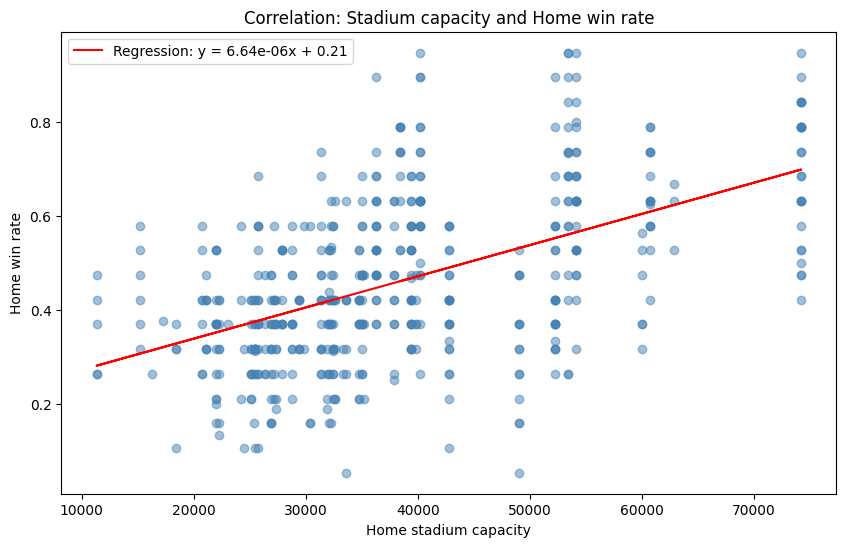

In [48]:
import numpy as np
import matplotlib.pyplot as plt

x = df_hwin_clubs['StadiumCapacity']
y = df_hwin_clubs['HomeWinRate']
a, b = np.polyfit(x, y, 1)

fig, ax = plt.subplots(figsize=(10, 6))
ax.set_xlabel('Home stadium capacity')
ax.set_ylabel('Home win rate')
ax.set_title('Correlation: Stadium capacity and Home win rate')
ax.scatter(x,y, alpha=0.5, color='steelblue')
ax.plot(x, a * x + b, color='red', label=f'Regression: y = {a:.2e}x + {b:.2f}')
ax.legend()
plt.show()

In [22]:
from scipy.stats import pearsonr

r, p_value = pearsonr(x, y)

print(f"Correlation coefficient (r): {r:.4f}")
print(f"p-value: {p_value:.4e}")

Correlation coefficient (r): 0.5222
p-value: 4.1402e-39


**Statistical Significance of Home Advantage**

The relationship between stadium capacity and home win rate was evaluated using Pearson’s correlation coefficient (r) and the associated p-value:

- Correlation Coefficient (r = $0.5222$): There is a moderate positive correlation between the variables. This suggests that as stadium capacity increases, there is a consistent upward trend in the home win rate across the dataset.
- P-value ($4.14 * 10^{-39}$): Since the p-value is far below the standard threshold of 0.05, we can confidently reject the null hypothesis and conclude that the observed correlation is not due to random chance.



**Add more conclusion here, I asked AI to write the part about r and p-value cuz I think we aren't familiar with it**

### **Grouped Bar Chart**

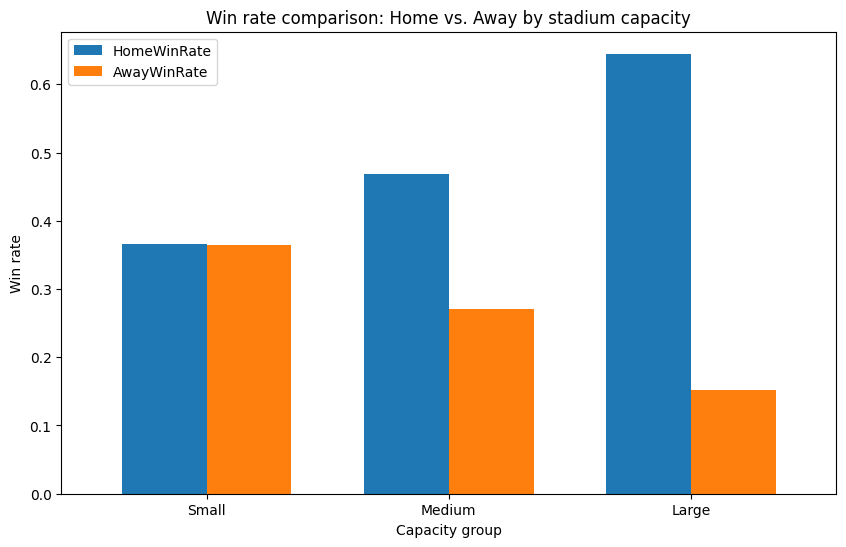

In [49]:
df_plot2 = df_hwin_awin.set_index('CapacityGroup')

fig, ax = plt.subplots(figsize=(10, 6))
df_plot2[['HomeWinRate', 'AwayWinRate']].plot(kind='bar', ax=ax, width=0.7)
ax.set_title('Win rate comparison: Home vs. Away by stadium capacity')
ax.set_xlabel('Capacity group')
ax.set_ylabel('Win rate')
plt.xticks(rotation=0)
plt.show()

**Add conclusion here**

### **Line Chart**

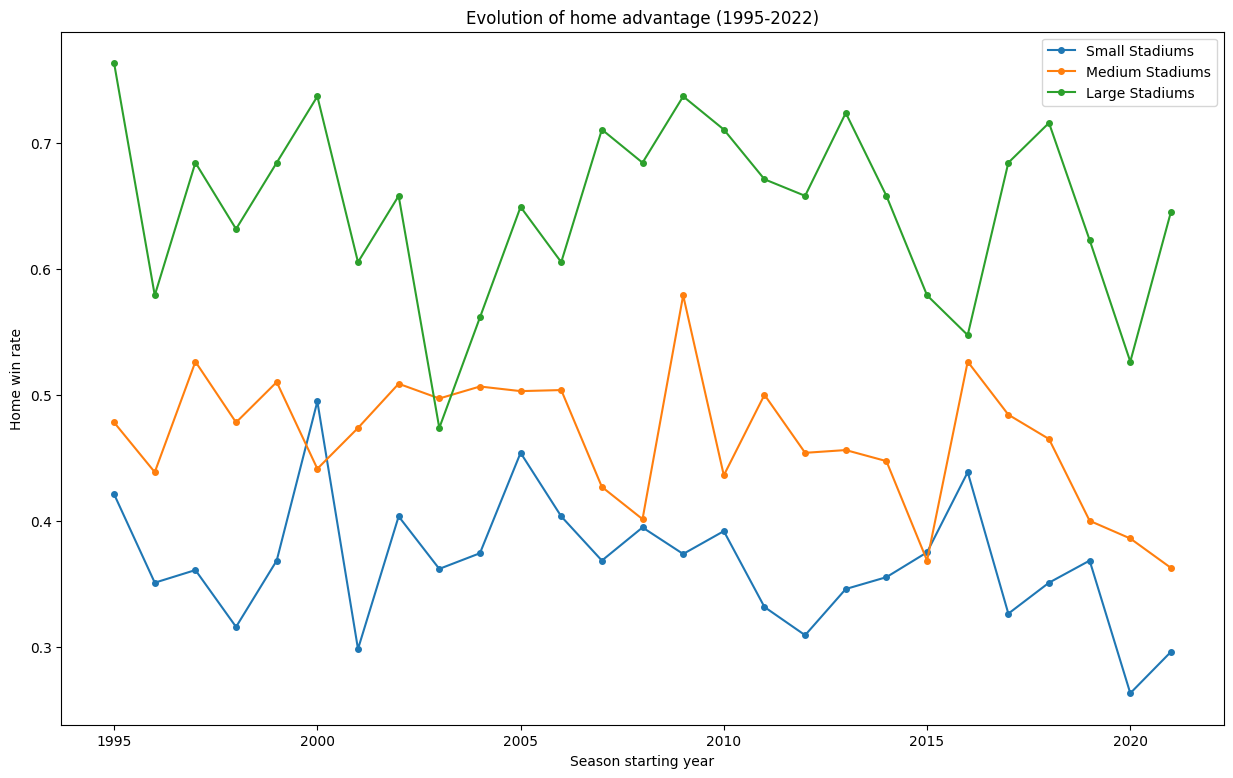

In [55]:
fig, ax = plt.subplots(figsize=(15, 9))

for group in ['Small', 'Medium', 'Large']:
    data = df_hwin_seasons[df_hwin_seasons['CapacityGroup'] == group]
    ax.plot(data['YearStart'], data['HomeWinRate'], label=f'{group} Stadiums', marker='o', markersize=4)

ax.set_title('Evolution of home advantage (1995-2022)')
ax.set_xlabel('Season starting year')
ax.set_ylabel('Home win rate')
ax.legend()
plt.show()

**Add conclusion here**

### **Bar chart**

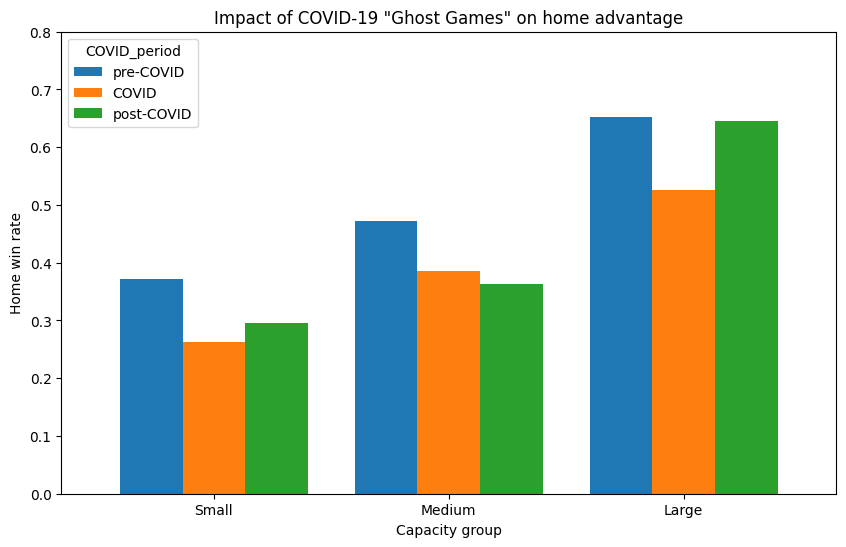

In [58]:
df_pivot = df_hwin_covid.pivot(index='CapacityGroup', columns='COVID_period', values='HomeWinRate')
df_pivot = df_pivot[['pre-COVID', 'COVID', 'post-COVID']]

fig, ax = plt.subplots(figsize=(10, 6))
ax = df_pivot.plot(kind='bar', ax=ax, width=0.8)

ax.set_title('Impact of COVID-19 "Ghost Games" on home advantage')
ax.set_xlabel('Capacity group')
ax.set_ylabel('Home win rate')
ax.set_ylim(0, 0.8)
plt.xticks(rotation=0)

plt.show()

In [42]:
display(df_pivot)

COVID_period,pre-COVID,COVID,post-COVID
CapacityGroup,,,
Small,0.372239,0.263158,0.296000
Medium,0.472732,0.385965,0.362637
Large,0.652999,0.526316,0.645161


**Add conclusion here**